# Sampling a continuous-wave signal on its own Fourier basis

This tutorial builds a pulsar-timing-array model that contains a **continuous-wave (CW) source carried on its own Fourier basis** -- "Route A" -- and samples it with NUTS.

The CW is added to a Hellings-Downs (HD) gravitational-wave-background model through `ArrayLikelihood(..., extsignals=[...])`. Unlike a Gaussian process, the CW has no prior: its Fourier coefficients are a deterministic function of a few physical parameters. Because it lives on its own basis it can use *more* frequency components than the red-noise / GWB GPs, so it reaches the higher frequencies a CW search needs (the bin spacing is fixed at `1/T_obs` for every Fourier basis).

The model has four pieces:

- **per-pulsar red noise** -- a `commongp` Fourier GP
- **an HD common-process GWB** -- a `globalgp` Fourier GP
- **decentering** -- `ArrayLikelihood(decenter=True)`, which samples the GP coefficients in a whitened (unit-normal) frame
- **a CW on its own basis** -- `extsignals=[makecw_extsignal(...)]`

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax
import matplotlib.pyplot as plt

import discovery as ds
# from discovery import Params
from discovery import metamath as mh
from discovery import metamatrix as mm

# enable .graph attribute on mm.func outputs so we can inspect the
# computation graph after model construction.
mm.keepgraph = True

# pull in the metamatrix monkeypatch from the parity-test scaffold so that
# building this model captures metamath kernels instead of matrix.py ones.
sys.path.insert(0, str(Path(ds.__path__[0]).parent.parent / 'tests'))
from metamatrix._patch import metamatrix_patch


## Load the pulsars

We use the first 10 pulsars from the `v1p1` feather files shipped alongside `discovery`.

In [2]:
datapath = Path(ds.__path__[0]) / '../../data'
psrs = [ds.Pulsar.read_feather(f)
        for f in sorted(datapath.glob('v1p1*.feather'))][:5]
print(f"loaded {len(psrs)} pulsars")

loaded 5 pulsars


## Build the model

`makecw_extsignal` builds the CW on its own Fourier basis with `n_cw` components. We choose `n_cw` larger than the red-noise (`n_rn`) and GWB (`n_gw`) component counts so the CW basis reaches higher frequencies.

The rest is a standard `ArrayLikelihood`: a `commongp` for per-pulsar red noise, a `globalgp` for the HD-correlated background, and `decenter=True` for whitened-frame sampling. The CW is wired in with `extsignals=[cw]`.

In [3]:
n_rn = 30   # red-noise Fourier components
n_gw = 14   # GWB Fourier components
n_cw = 60   # CW Fourier components (own basis -- larger on purpose)
hd = True
T = ds.getspan(psrs)

if not hd:
    with metamatrix_patch():
        cw = ds.makecw_extsignal(psrs, components=n_cw, T=T, pulsarterm=True)

        model = ds.ArrayLikelihood(
            [ds.PulsarLikelihood([psr.residuals,
                                ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True),
                                ds.makegp_timing(psr, svd=True)])
            for psr in psrs],
            commongp=ds.makecommongp_fourier(psrs, ds.makepowerlaw_crn(14), components=n_rn,
                                            T=T, name='red_noise', common=['crn_gamma', 'crn_log10_A']),
            decenter=True, extsignals=[cw])

        # force the cached_property to be built INSIDE the patch context so the
        # graph captures metamath objects.
        _ = model.clogL
        _ = model.logL

    print(f"{len(model.clogL.params)} sampled parameters "
        f"({len(cw.params)} of them CW)")

# n_rn = 30   # red-noise Fourier components
# n_gw = 14   # GWB Fourier components
# n_cw = 60   # CW Fourier components (own basis -- larger on purpose)

# T = ds.getspan(psrs)
else:
    with metamatrix_patch():
        cw = ds.makecw_extsignal(psrs, components=n_cw, T=T, pulsarterm=True)

        model = ds.ArrayLikelihood(
            [ds.PulsarLikelihood([psr.residuals,
                                ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True),
                                ds.makegp_timing(psr, svd=True)])
            for psr in psrs],
            commongp=ds.makecommongp_fourier(psrs, ds.powerlaw, components=n_rn,
                                            T=T, name='red_noise'),
            globalgp=ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf,
                                            components=n_gw, T=T, name='gw'),
            decenter=True, extsignals=[cw])

        _ = model.clogL
        _ = model.logL

    print(f"{len(model.clogL.params)} sampled parameters "
        f"({len(cw.params)} of them CW)")


34 sampled parameters (12 of them CW)


In [10]:
ds.priordict_standard

{'(.*_)?efac': [0.1, 10],
 '(.*_)?t2equad': [-8.5, -5],
 '(.*_)?tnequad': [-8.5, -5],
 '(.*_)?log10_ecorr': [-8.5, -5],
 '(.*_)?rednoise_log10_A.*': [-20, -11],
 '(.*_)?rednoise_gamma.*': [0, 7],
 '(.*_)?rednoise_log10_fb': [-9, -6],
 '(.*_)?red_noise_log10_A.*': [-20, -11],
 '(.*_)?red_noise_gamma.*': [0, 7],
 '(.*_)?red_noise_log10_fb': [-9, -6],
 'crn_log10_A.*': [-18, -11],
 'crn_gamma.*': [0, 7],
 'crn_log10_fb': [-9, -6],
 'gw_(.*_)?log10_A': [-18, -11],
 'gw_(.*_)?gamma': [0, 7],
 'gw_log10_fb': [-9, -6],
 '(.*_)?dmgp_log10_A': [-20, -11],
 '(.*_)?dmgp_gamma': [0, 7],
 '(.*_)?dmgp_alpha': [1, 3],
 'crn_log10_rho': [-9, -4],
 'gw_(.*_)?log10_rho': [-9, -4],
 '(.*_)?red_noise_log10_rho\\(([0-9]*)\\)': [-9, -4],
 '(.*_)?red_noise_crn_log10_rho\\(([0-9]*)\\)': [-9, -4],
 'cw_ra': [0, 6.283185307179586],
 'cw_dec': [-1.5707963267948966, 1.5707963267948966],
 'cw_inc': [0, 3.141592653589793],
 'cw_sindec': [-1.0, 1.0],
 'cw_cosinc': [-1.0, 1.0],
 'cw_psi': [0, 3.141592653589793],
 'cw

## Look at the clogL computation graph

`model.clogL` now wraps a metamath graph. With `mm.keepgraph = True` the
callable carries `.graph` (the folded/pruned graph that runs at every
sample) and `.graph.subgraphs` (the un-folded sub-graphs like
`N.make_solve` and `P.make_inv`). Below we print a text summary and write
an SVG of the top-level graph.


In [4]:
# top-level (folded, pruned) graph
mm.print_graph(model.clogL.graph)


## graph
coeffs: func = <function VectorWoodburyKernel.make_kernelproduct_gpcomponent.<locals>._coeffs at 0x43cd40680>
means: const = 0.0
ext_coeffs_0: func = <function make_extsignal_fourier.<locals>.coeffs at 0x377f39260>
n47: const = array(5, 88)
n48: const = array(5, 88, 88)
n49: node(coeffs) = coeffs[0]
n50: node(coeffs) = coeffs[1]
n51: node(n49, means) = n49 - means
prior_n52: graph = subgraph prior_n52[5dd1]
n52: node(prior_n52, n51) = prior(n51)
n53: node(n49, n48) = c.T @ FtNmF @ c
n54: node(n49, n47) = sum(c * NmFty)
n55: const = array()
n56: node(n55, n54) = n55 + n54
n57: node(n53) = 0.5 * n53
n58: node(n56, n57) = n56 - n57
n59: const = array()
n60: node(n58, n59) = n58 - n59
n61: node(n60, n52) = n60 + n52
n62: node(n61, n50) = n61 + n50
n78: const = array(5, 120)
n89: const = array(5, 88, 120)
n100: const = array(5, 120, 120)
n101: node(ext_coeffs_0, n78) = sum(ccw * FcwNmy)
n102: node(n49, n89, ext_coeffs_0) = c.T @ FtNmFcw @ ccw
n103: node(ext_coeffs_0, n100) = ccw.T 

164562

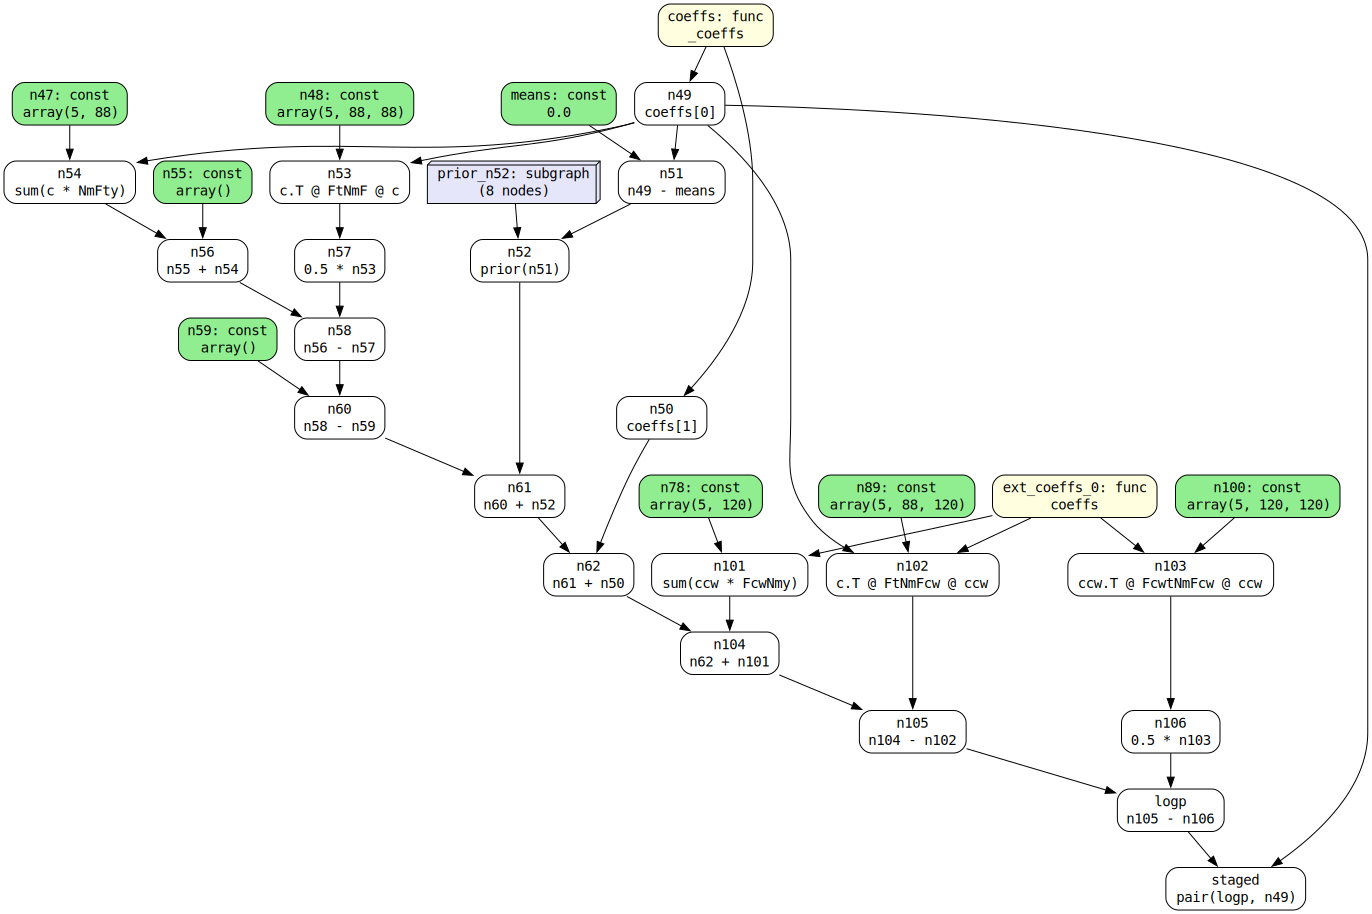

In [5]:
# render an SVG of the graph
mm.visualize_graph(model.clogL.graph, fold=False, format='svg')


## Evaluate the coefficient likelihood

With `decenter=True` the quantity we sample is `clogL` -- the *coefficient* likelihood, a function of the GP hyperparameters, the whitened GP coefficients, and the CW parameters. The CW enters `clogL` through GP-CW cross-terms; its parameters never touch the GP prior.

Here is a single evaluation at a test point, just to confirm the model is wired up. We draw the hyperparameters from their priors, the whitened (decentered) GP coefficients as unit normals, and fix the CW at a non-degenerate point.

In [6]:
rng = np.random.default_rng(0)
pars = ds.sample_uniform(model.logL.params)

# decentered GP coefficients are sampled in a whitened (unit-normal) frame
for psr in psrs:
    pars[f'{psr.name}_gw_coefficients({2 * n_gw})'] = rng.standard_normal(2 * n_gw)
    pars[f'{psr.name}_red_noise_coefficients({2 * n_rn})'] = rng.standard_normal(2 * n_rn)

# CW parameters at a fixed, non-degenerate point
for k in cw.params:
    if k.endswith('log10_h0'):
        pars[k] = -14.0
    elif k.endswith('log10_f0'):
        pars[k] = -7.7
    elif k.endswith('sindec') or k.endswith('cosinc'):
        pars[k] = 0.3
    elif k.endswith('phi_psr'):
        pars[k] = rng.uniform(0, 2 * np.pi)
    elif k == 'cw_phi_earth':
        pars[k] = 1.7
    else:
        pars[k] = 0.5

clogl = jax.jit(model.clogL)
P = pars # Params.from_dict(pars, names=model.clogL.params)
print("clogL at test point =", float(clogl(P)[0]))

clogL at test point = 885499.2601169792


In [7]:
model.clogL.params

['B1855+09_cw_phi_psr',
 'B1855+09_gw_coefficients(28)',
 'B1855+09_red_noise_coefficients(60)',
 'B1855+09_red_noise_gamma',
 'B1855+09_red_noise_log10_A',
 'B1937+21_cw_phi_psr',
 'B1937+21_gw_coefficients(28)',
 'B1937+21_red_noise_coefficients(60)',
 'B1937+21_red_noise_gamma',
 'B1937+21_red_noise_log10_A',
 'B1953+29_cw_phi_psr',
 'B1953+29_gw_coefficients(28)',
 'B1953+29_red_noise_coefficients(60)',
 'B1953+29_red_noise_gamma',
 'B1953+29_red_noise_log10_A',
 'J0023+0923_cw_phi_psr',
 'J0023+0923_gw_coefficients(28)',
 'J0023+0923_red_noise_coefficients(60)',
 'J0023+0923_red_noise_gamma',
 'J0023+0923_red_noise_log10_A',
 'J0030+0451_cw_phi_psr',
 'J0030+0451_gw_coefficients(28)',
 'J0030+0451_red_noise_coefficients(60)',
 'J0030+0451_red_noise_gamma',
 'J0030+0451_red_noise_log10_A',
 'cw_cosinc',
 'cw_log10_f0',
 'cw_log10_h0',
 'cw_phi_earth',
 'cw_psi',
 'cw_ra',
 'cw_sindec',
 'gw_gamma',
 'gw_log10_A']

## Sample with NUTS

We sample the decentered model with NUTS from `numpyro`. The sample sites are:

- `xi` -- the whitened GP coefficients, as **one array-shaped site** of shape `(npsr, 2*(n_rn + n_gw))` (not one site per pulsar)
- `gammas`, `log10_As` -- the red-noise and GWB power-law hyperparameters
- the CW earth-term parameters (`cw_log10_h0`, `cw_log10_f0`, ...)
- `cw_phi_psr` -- the per-pulsar CW pulsar-term phases

The model assembles these into the parameter dict that `clogL` expects and adds the log-likelihood with `numpyro.factor`.

In [13]:
import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer

jclogl = jax.jit(model.clogL)
npsr = len(psrs)
earth = ['cw_log10_h0', 'cw_log10_f0', 'cw_ra', 'cw_sindec',
         'cw_cosinc', 'cw_psi', 'cw_phi_earth']


def cw_model(hd=True):
    if hd:
        xi = numpyro.sample("xi", dist.Normal(0, 100).expand([npsr, 2 * (n_rn + n_gw)]))
    else:
        xi = numpyro.sample("xi", dist.Normal(0, 100).expand([npsr, 2 * (n_rn)]))
    gammas = numpyro.sample("gammas", dist.Uniform(0, 7).expand([npsr + 1]))
    log10_As = numpyro.sample("log10_As", dist.Uniform(-20, -11).expand([npsr + 1]))

    # CW earth-term parameters
    h0 = numpyro.sample("cw_log10_h0", dist.Uniform(-18.0, -11.0))
    f0 = numpyro.sample("cw_log10_f0", dist.Uniform(-9.0, -7.0))
    ra = numpyro.sample("cw_ra", dist.Uniform(0.0, 2 * np.pi))
    sd = numpyro.sample("cw_sindec", dist.Uniform(-1.0, 1.0))
    ci = numpyro.sample("cw_cosinc", dist.Uniform(-1.0, 1.0))
    psi = numpyro.sample("cw_psi", dist.Uniform(0.0, np.pi))
    phe = numpyro.sample("cw_phi_earth", dist.Uniform(0.0, 2 * np.pi))
    phi_psr = numpyro.sample("cw_phi_psr", dist.Uniform(0, 2 * np.pi).expand([npsr]))

    pars = {f'{p.name}_red_noise_log10_A': log10_As[i] for i, p in enumerate(psrs)}
    pars.update({f'{p.name}_red_noise_gamma': gammas[i] for i, p in enumerate(psrs)})
    if hd:
        pars.update({'gw_log10_A': log10_As[-1], 'gw_gamma': gammas[-1]})
        pars.update({f'{p.name}_gw_coefficients({2 * n_gw})': xi[i, 2 * n_rn:2*n_rn + 2*n_gw]
                for i, p in enumerate(psrs)})
    else:
        pars.update({'crn_log10_A': log10_As[-1], 'crn_gamma': gammas[-1]})
    pars.update({f'{p.name}_red_noise_coefficients({2 * n_rn})': xi[i, :2 * n_rn]
                 for i, p in enumerate(psrs)})
    # pars.update({f'{p.name}_crn_coefficients({2 * n_gw})': xi[i, 2 * n_rn:]
                #  for i, p in enumerate(psrs)})
    pars.update(dict(zip(earth, (h0, f0, ra, sd, ci, psi, phe))))
    pars.update({f'{p.name}_cw_phi_psr': phi_psr[i] for i, p in enumerate(psrs)})

    ll, _ = jclogl(pars)
    numpyro.deterministic("loglike", ll)
    numpyro.factor("ll", ll)

Run the sampler. The warmup/sample counts below are small so the tutorial finishes quickly -- increase them substantially for a production run.

In [14]:
kernel = infer.NUTS(cw_model, max_tree_depth=8, target_accept_prob=0.8)
sampler = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1)
sampler.run(jax.random.key(42))
sampler.print_summary(exclude_deterministic=True)

sample: 100%|██████████| 400/400 [03:02<00:00,  2.19it/s, 255 steps of size 3.07e-03. acc. prob=0.99]


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     cw_cosinc      0.09      0.54      0.18     -0.70      0.89     14.34      1.11
   cw_log10_f0     -7.55      0.36     -7.44     -8.00     -7.12      9.68      1.17
   cw_log10_h0    -15.84      1.22    -16.20    -17.60    -14.16      3.54      2.03
  cw_phi_earth      1.08      1.09      0.64      0.00      2.93     13.60      1.03
 cw_phi_psr[0]      3.08      1.91      3.02      0.05      5.67      6.96      1.28
 cw_phi_psr[1]      2.08      1.54      1.55      0.09      4.69      9.34      1.00
 cw_phi_psr[2]      4.05      1.80      4.61      1.15      6.25      9.89      1.34
 cw_phi_psr[3]      3.58      1.88      3.86      0.56      6.24      6.78      1.32
 cw_phi_psr[4]      2.92      1.50      2.89      0.97      5.61     24.11      1.06
        cw_psi      1.53      0.70      1.57      0.36      2.56     16.77      1.14
         cw_ra      3.98      1.79      4.58      1.03      6.24

## Look at the posterior

The samples come back as a dict of arrays. As a quick look, here is the marginal posterior on the CW strain amplitude `cw_log10_h0`.

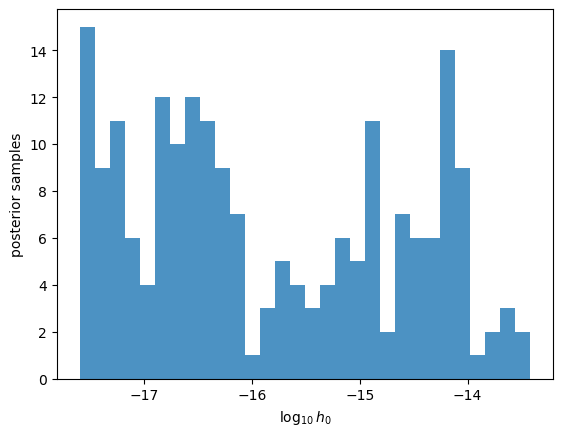

In [16]:
samples = sampler.get_samples()

plt.hist(np.asarray(samples['cw_log10_h0']), bins=30,
         histtype='stepfilled', alpha=0.8)
plt.xlabel(r'$\log_{10} h_0$')
plt.ylabel('posterior samples')
plt.show()

In [17]:
from corner import corner

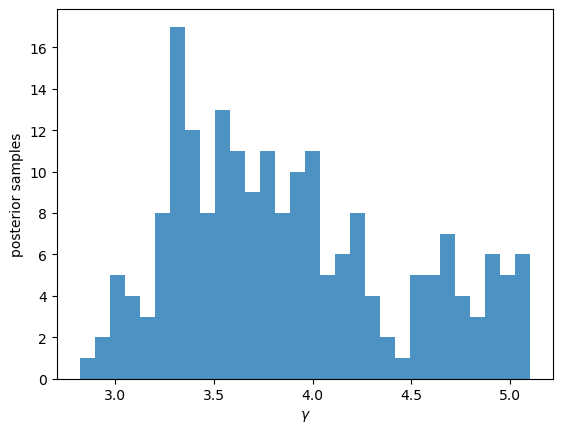

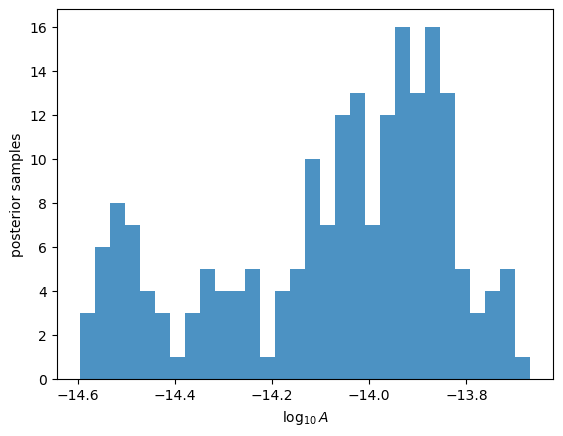

In [18]:
plt.hist(np.asarray(samples['gammas'][:, -1]), bins=30,
         histtype='stepfilled', alpha=0.8)
plt.xlabel(r'$\gamma$')
plt.ylabel('posterior samples')
plt.show()

plt.hist(np.asarray(samples['log10_As'][:, -1]), bins=30,
         histtype='stepfilled', alpha=0.8)
plt.xlabel(r'$\log_{10} A$')
plt.ylabel('posterior samples')
plt.show()